# M11.15 — Result interpretation

Interpretación descriptiva de artefactos finales M10/M11. Sin nueva inferencia,
GPU, señales, embeddings, entrenamiento o cambios a sistemas congelados.
Test sintéticos distintos: comparar tendencias, nunca tratarlos como muestras pareadas.
En reales, LVK ubica el evento de forma diagnóstica y es referencia posterior,
no verdad exacta. No concluir causalidad a partir de asociaciones.

**Alcance de los inputs:** sólo está disponible el HDF5 M11 entre las fuentes
permitidas. Distancia y densidad usan **train_M11 como referencia común** para ambos
tests y eventos reales; no se presentan como distancia al train propio de M10.
Los scalers de cada NPZ sí permiten z por label respecto a su propio train.
SNR/duración sintéticos son exclusivamente M11: índices M10 y M11 no son fuentes
emparejadas y no se puede asignar metadata M11 a M10. Esta carencia se conserva
como limitación; no se carga otro dataset ni se sustituye train por cal/test.

## 1. Inputs y contratos

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.neighbors import NearestNeighbors
from IPython.display import display

root = next((p for p in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
             if (p / "src/paths.py").is_file()), None)
if root is None:
    raise RuntimeError("Abrir desde cbc_pe")
if str(root) not in sys.path:
    sys.path.insert(0, str(root))
from src.paths import resolve_project_root, resolve_data_root, resolve_processed_artifact
PROJECT_ROOT = resolve_project_root()
DATA_ROOT = resolve_data_root(config_data_root="/data/vserrano/cbc_pe_data")
LABELS = ["chirp_mass", "total_mass", "chi_eff"]
PRED_PATHS = {
    "M10": DATA_ROOT / "results/bbh_processed_4s_seobnrv4opt_snr10-25_n500_000/m10_inputzscore_500k_cal_test_predictions_embeddings.npz",
    "M11": DATA_ROOT / "results/M11_final_G1_500k/m11_final_G1_500k_cal_test_predictions_embeddings.npz",
}
HDF5_PATH = resolve_processed_artifact(data_root=DATA_ROOT, dataset_id="M11_final_G1_500k",
    file_name="m11_final_G1_500k_trainio.h5", allow_legacy_flat=False)
REAL_DIR = DATA_ROOT / "results/M11_final_G1_500k/real_events/multi_event"
REAL_PATHS = {name: REAL_DIR / f"{name}.csv" for name in
              ("event_status", "per_event_comparison", "event_predictions")}
OUTPUT_DIR = DATA_ROOT / "results/M11_final_G1_500k/M11_15_result_interpretation"
def require(condition, message):
    if not condition:
        raise ValueError(message)
for path in [*PRED_PATHS.values(), HDF5_PATH, *REAL_PATHS.values()]:
    require(path.is_file(), f"Missing input: {path}")

tests = {}
for model,path in PRED_PATHS.items():
    # Lazy NPZ access: never load embedding or calibration arrays.
    with np.load(path, allow_pickle=False) as z:
        require(z["label_names"].tolist() == LABELS, f"Labels {model}")
        mean, std = (np.asarray(z[k], dtype=float) for k in ("y_mean", "y_std"))
        truth_std, prediction_std = (np.asarray(z[k], dtype=float) for k in ("y_test", "pred_test"))
        indices = z["idx_test"].copy()
    require(mean.shape == std.shape == (3,) and np.isfinite(mean).all()
            and np.isfinite(std).all() and (std>0).all(), f"Scaler {model}")
    require(truth_std.shape == prediction_std.shape == (30000,3), f"Test shapes {model}")
    require(np.isfinite(truth_std).all() and np.isfinite(prediction_std).all(), f"Finite {model}")
    require(indices.shape == (30000,) and np.issubdtype(indices.dtype, np.integer)
            and len(np.unique(indices)) == len(indices), f"IDs {model}")
    truth, prediction = truth_std*std+mean, prediction_std*std+mean
    tests[model] = dict(truth=truth, prediction=prediction, residual=prediction-truth,
                        indices=indices, train_mean=mean, train_std=std)
status = pd.read_csv(REAL_PATHS["event_status"])
paired = pd.read_csv(REAL_PATHS["per_event_comparison"])
real_predictions = pd.read_csv(REAL_PATHS["event_predictions"])
require(not status.event.duplicated().any(), "Duplicate real event status")
require(not paired.duplicated(["event", "label"]).any(), "Duplicate comparison rows")
require(not real_predictions.duplicated(["event", "model", "label"]).any(), "Duplicate real predictions")
require(set(paired.label) == set(LABELS), "Real labels")
require(set(paired.event) <= set(status.loc[status.processing_status == "success", "event"]), "Invalid real cohort")
require(set(real_predictions.frame) <= {"detector", "dimensionless"}, "Real physical frame")
for label in LABELS:
    expected_frame = "dimensionless" if label == "chi_eff" else "detector"
    require(real_predictions.loc[real_predictions.label == label, "frame"].eq(expected_frame).all(), "Mixed frames")
for model in tests:
    saved = real_predictions[real_predictions.model == model][["event", "label", "prediction"]]
    check = paired.merge(saved, on=["event", "label"], validate="one_to_one")
    require(len(check) == len(paired) and np.isfinite(check[["lvk_central", "prediction"]]).all().all(), "Real missing/finite")
    require(np.allclose(check.prediction, check[f"prediction_{model}"]), "Real prediction mismatch")
    require(np.allclose(np.abs(check.prediction-check.lvk_central), check[f"absolute_discrepancy_{model}"]), "Real discrepancy mismatch")
real = paired.pivot(index="event", columns="label", values="lvk_central").reindex(columns=LABELS)
require(np.isfinite(real.to_numpy()).all(), "Incomplete LVK coordinates")
real.columns = [f"{label}_lvk" for label in LABELS]
real = real.reset_index().merge(status[["event", "network_snr_lvk"]], on="event", validate="one_to_one")
for model in tests:
    for label in LABELS:
        mapping = paired[paired.label == label].set_index("event")[f"absolute_discrepancy_{model}"]
        real[f"{model}_{label}_discrepancy"] = real.event.map(mapping)
real_coordinates = real[[f"{label}_lvk" for label in LABELS]].to_numpy(float)
print("Synthetic test lengths:", {m:len(t["truth"]) for m,t in tests.items()})
display(status[["event", "processing_status", "network_snr_lvk"]])

Synthetic test lengths: {'M10': 30000, 'M11': 30000}


,event,processing_status,network_snr_lvk
0,GW200202_154313,success,10.8
1,GW191129_134029,skipped,13.1
2,GW200316_215756,success,10.3
3,GW200225_060421,skipped,12.5
4,GW191215_223052,success,11.2
5,GW200129_065458,success,26.8
6,GW200311_115853,success,17.8
7,GW200208_130117,success,10.8
8,GW200224_222234,success,20.0
9,GW200219_094415,success,10.7


In [2]:
# Allowlist is the only HDF5 access route. Signals are never read.
ALLOWED = {"y", "split", "chirp_mass", "total_mass", "chi_eff", "final_network_snr",
           "full_network_duration", "is_truncated", "mass_1", "mass_2"}
def read_metadata(h, name):
    require(name in ALLOWED, f"Forbidden HDF5 field: {name}")
    return h[name][:]
with h5py.File(HDF5_PATH, "r") as h:
    require(h.attrs.get("experiment_id") == "M11_final_G1_500k", "Wrong HDF5")
    require(h.attrs.get("labels") == ",".join(LABELS), "HDF5 label order")
    missing_metadata = sorted(ALLOWED-set(h.keys()))
    require(not missing_metadata, f"Missing required metadata: {missing_metadata}")
    split_raw = read_metadata(h, "split")
    splits = np.array([s.decode() if isinstance(s,bytes) else str(s) for s in split_raw])
    y_physical = np.asarray(read_metadata(h, "y"), dtype=float)
    require(y_physical.shape == (500000,3) and np.isfinite(y_physical).all(), "Physical labels")
    train_indices = np.flatnonzero(splits == "train")
    require(len(train_indices) == 400000, "Train split size")
    idx = tests["M11"]["indices"]
    require(np.all((idx>=0)&(idx<len(splits))) and (splits[idx] == "test").all(), "M11 test ID alignment")
    require(np.array_equal(np.sort(idx), np.flatnonzero(splits == "test")), "M11 exact test membership")
    require(np.allclose(y_physical[idx], tests["M11"]["truth"], rtol=2e-6, atol=2e-5),
            "HDF5 y must already be physical; no second inverse transform")
    train_y = y_physical[train_indices].copy()
    metadata = {}
    for field in sorted(ALLOWED-{"y", "split"}):
        require(h[field].ndim == 1 and h[field].shape == (500000,), f"Metadata shape {field}")
        # Scalar arrays only: select in memory to preserve prediction artifact order.
        metadata[field] = read_metadata(h, field)[idx]
        require(np.isfinite(metadata[field]).all(), f"Metadata finite {field}")
    for j,label in enumerate(LABELS):
        require(np.allclose(metadata[label], tests["M11"]["truth"][:,j], rtol=2e-6, atol=2e-5), f"Physical label {label}")
    require(h.attrs.get("snr_low_frequency_cutoff") == 30.0
            and h.attrs.get("snr_high_frequency_cutoff") == 512.0, "M11 SNR definition")
del y_physical, split_raw, splits
train_mu = train_y.mean(axis=0)
train_sigma = train_y.std(axis=0)
require((train_sigma>0).all(), "Degenerate train scale")
display(pd.DataFrame(dict(label=LABELS, train_M11_mean=train_mu, train_M11_std=train_sigma)))
print("M10 train covariance/local density and per-sample SNR unavailable in supplied inputs.")

,label,train_M11_mean,train_M11_std
0,chirp_mass,37.463257,16.508970
1,total_mass,94.986031,34.705112
2,chi_eff,-0.000219,0.440367


M10 train covariance/local density and per-sample SNR unavailable in supplied inputs.


## Helpers descriptivos

Cuantiles calculados por test, sin ajustar predictor. Los límites y conteos se guardan;
empates colapsan bins degenerados, no se rompen con jitter. En tablas condicionadas
se muestran métricas sólo con n≥30 (umbral descriptivo, no garantía estadística).
Errores conservan unidades físicas por label. No se mezclan unidades en un error global.
Los scatter se limitan a 3000 puntos deterministas por legibilidad; todos los
estadísticos usan el test completo. Percentiles empíricos usan fracción ≤ valor.

In [3]:
MIN_COUNT = 30
SCATTER_STEP = 10

def error_metrics(values):
    v = np.asarray(values, dtype=float)
    n = len(v)
    if n < MIN_COUNT:
        return dict(n=n, sufficient_count=False, RMSE=np.nan, MAE=np.nan, bias=np.nan,
                    median_residual=np.nan, p16=np.nan, p84=np.nan)
    return dict(n=n, sufficient_count=True, RMSE=float(np.sqrt(np.mean(v*v))),
                MAE=float(np.mean(np.abs(v))), bias=float(v.mean()),
                median_residual=float(np.median(v)), p16=float(np.quantile(v,.16)), p84=float(np.quantile(v,.84)))

def quantile_bins(values, q=5):
    values = np.asarray(values, dtype=float)
    require(np.isfinite(values).all(), "Nonfinite bin variable")
    edges = np.unique(np.quantile(values, np.linspace(0,1,q+1)))
    if len(edges) == 1:
        return np.zeros(len(values), dtype=int)
    return np.searchsorted(edges[1:-1], values, side="right")

def grouped_metrics(model, analysis, dimensions):
    t = tests[model]
    frame = pd.DataFrame({name: quantile_bins(v, q) for name,(v,q) in dimensions.items()})
    rows = []
    for key, positions in frame.groupby(list(dimensions), sort=True).indices.items():
        key = key if isinstance(key,tuple) else (key,)
        group = dict(zip(dimensions,key))
        for name,(v,_) in dimensions.items():
            group[f"{name}_min"] = float(np.asarray(v)[positions].min())
            group[f"{name}_max"] = float(np.asarray(v)[positions].max())
        for j,label in enumerate(LABELS):
            rows.append(dict(model=model, analysis=analysis, label=label, **group,
                             **error_metrics(t["residual"][positions,j])))
    return pd.DataFrame(rows)

def percentile(values, reference):
    return 100*np.searchsorted(np.sort(reference), values, side="right")/len(reference)

def binned_error_plot(table, bin_name, title):
    fig,axes = plt.subplots(1,3,figsize=(14,3.5))
    for ax,label in zip(axes,LABELS):
        for model,sub in table[table.label == label].groupby("model"):
            ax.plot(sub[bin_name],sub.RMSE,"o-",label=model)
        ax.set(title=label,xlabel=bin_name,ylabel="RMSE (physical units)")
    axes[0].legend(); fig.suptitle(title); fig.tight_layout(); plt.show()

## 2. Distribuciones true/predicted y regresión a la media

z_j=(truth−train_mean_j)/train_std_j usa el scaler train-only propio de cada NPZ.
El residual es predicción−truth; mediana y banda 16–84% son dispersión de residuos,
no intervalos de confianza. La compresión de std y un sesgo condicionado hacia
el centro se describen sin aplicar ninguna corrección.

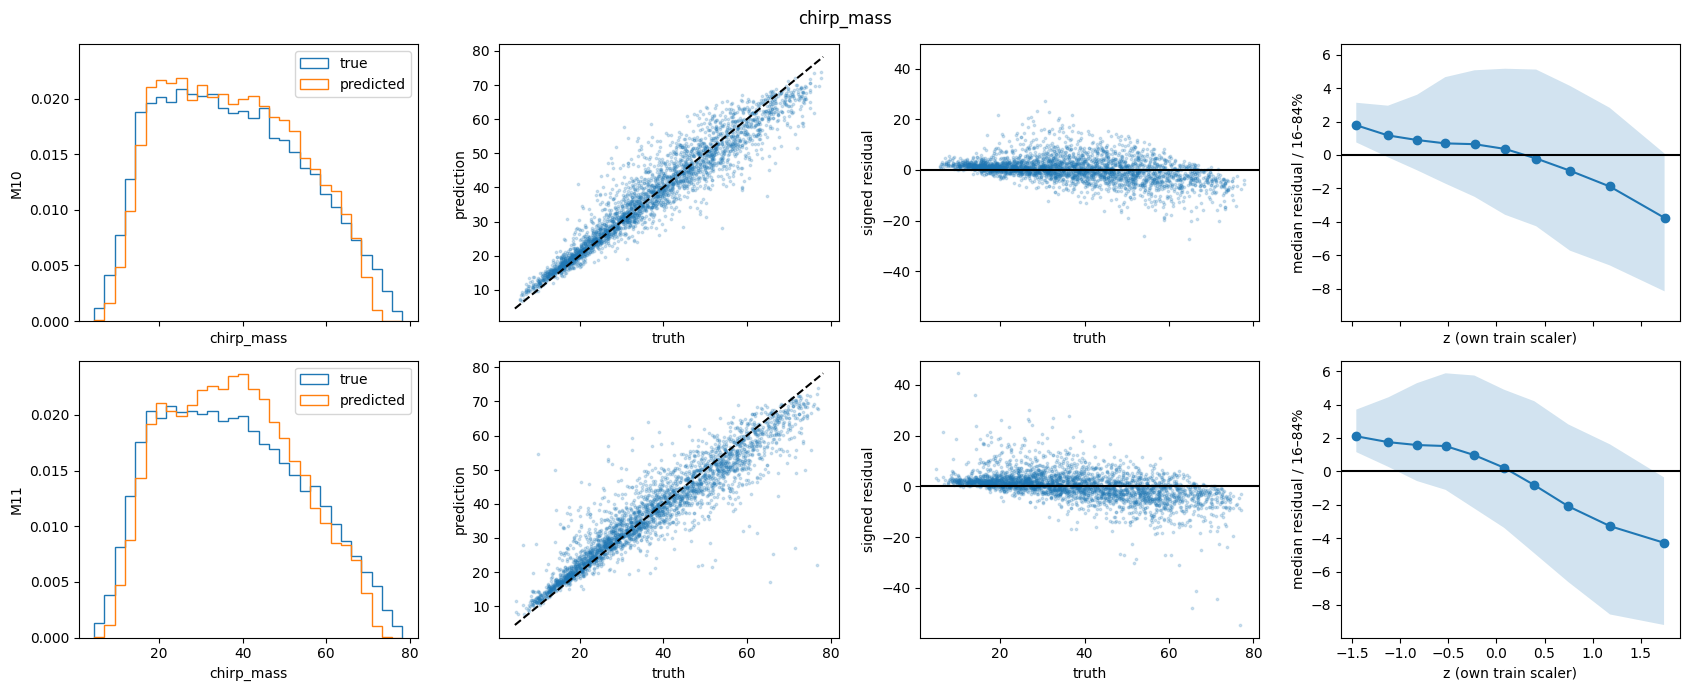

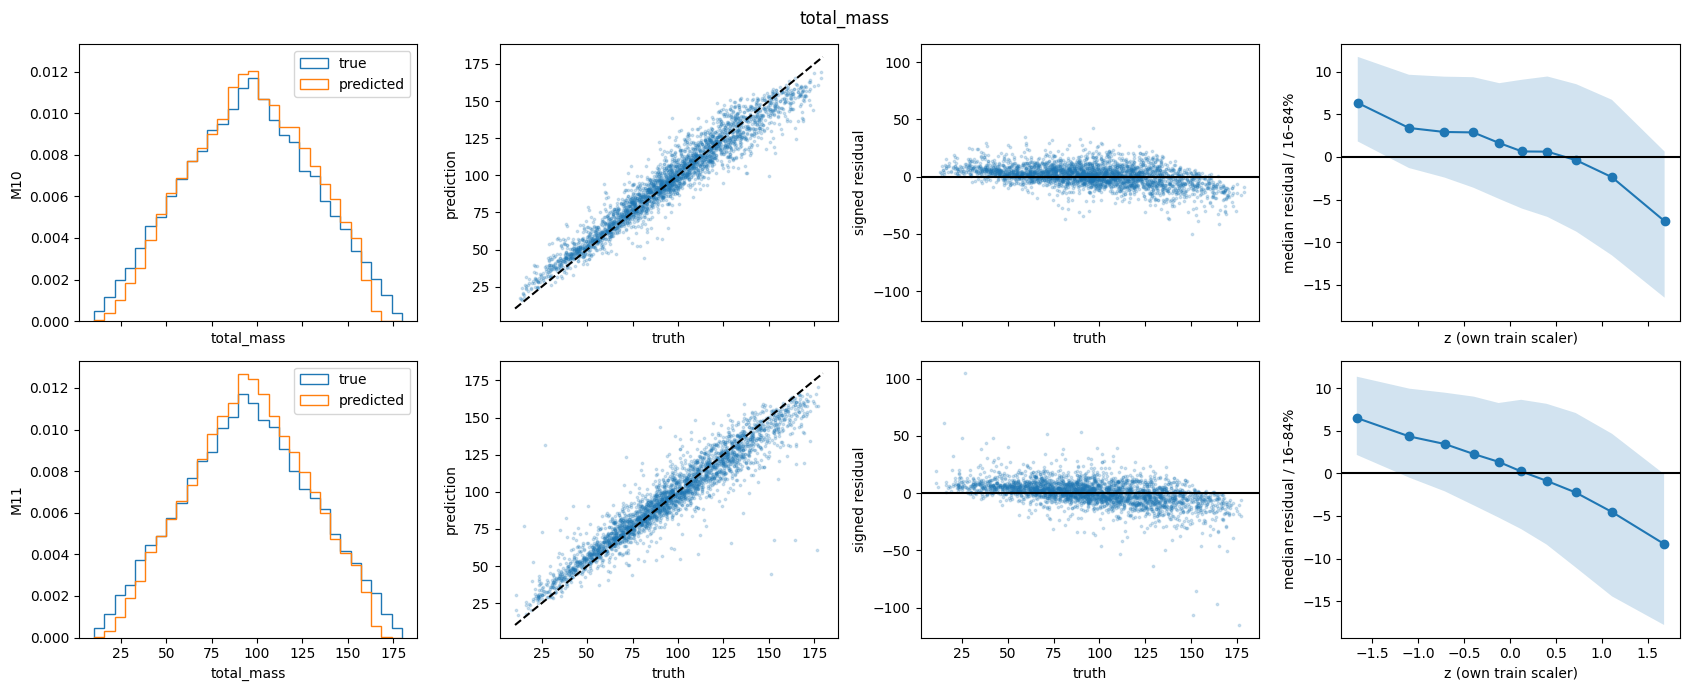

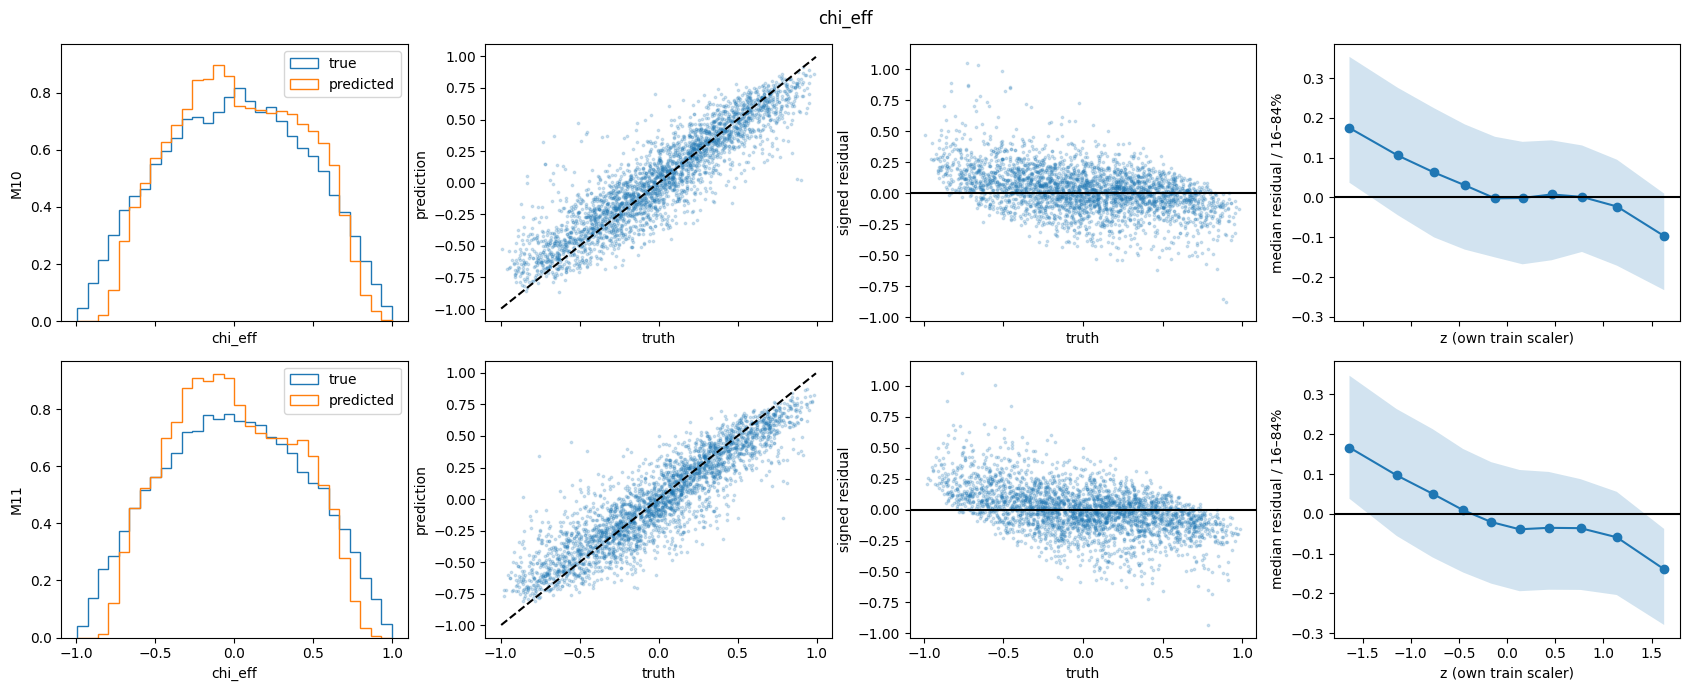

,model,label,n,true_mean,true_std,pred_mean,pred_std,std_ratio
0,M10,chirp_mass,30000,37.516866,16.532229,37.734766,15.386061,0.930671
1,M11,chirp_mass,30000,37.461688,16.493347,37.616105,14.708843,0.891805
2,M10,total_mass,30000,95.136047,34.678916,96.214542,31.953771,0.921418
3,M11,total_mass,30000,95.063919,34.582361,95.397854,31.274277,0.904342
4,M10,chi_eff,30000,0.004608,0.440322,0.028254,0.394881,0.896802
5,M11,chi_eff,30000,-0.003891,0.440409,-0.008509,0.381510,0.866261


,model,label,z_bin,z_min,z_max,z_median,n,sufficient_count,RMSE,MAE,bias,median_residual,p16,p84
0,M10,chirp_mass,0,-1.994494,-1.280556,-1.457694,3000,True,2.695674,2.110464,1.993345,1.776653,0.747982,3.123889
1,M10,chirp_mass,1,-1.280527,-0.978335,-1.128149,3000,True,3.347779,2.002952,1.656961,1.167240,-0.138297,2.947938
2,M10,chirp_mass,2,-0.978154,-0.677517,-0.825032,3000,True,4.269345,2.454259,1.626694,0.892429,-0.920195,3.602019
3,M10,chirp_mass,3,-0.677379,-0.376746,-0.532151,3000,True,4.820521,3.058662,1.596278,0.691278,-1.716128,4.657454
4,M10,chirp_mass,4,-0.376610,-0.072687,-0.227473,3000,True,5.248929,3.520077,1.467889,0.643297,-2.507766,5.067574
5,M10,chirp_mass,5,-0.072664,0.250517,0.089012,3000,True,5.247924,3.799010,0.873772,0.358922,-3.582775,5.161715
6,M10,chirp_mass,6,0.250539,0.577171,0.413450,3000,True,5.200119,3.910510,0.217338,-0.214622,-4.270174,5.111515
7,M10,chirp_mass,7,0.577241,0.956620,0.764700,3000,True,5.484447,4.183775,-0.901147,-0.944182,-5.732357,4.135247
8,M10,chirp_mass,8,0.956981,1.429031,1.178702,3000,True,5.619743,4.262466,-2.087749,-1.889073,-6.614821,2.820004
9,M10,chirp_mass,9,1.429083,2.445861,1.748978,3000,True,6.425410,4.861641,-4.264379,-3.770907,-8.169405,0.080458


In [14]:
distribution_rows, regression_tables = [], []
for j,label in enumerate(LABELS):
    fig,axes = plt.subplots(2,4,figsize=(17,7),sharex="col",sharey="col")
    all_values = np.concatenate([t[k][:,j] for t in tests.values() for k in ("truth","prediction")])
    edges = np.linspace(all_values.min(),all_values.max(),31)
    for row,(model,t) in enumerate(tests.items()):
        y,p = t["truth"][:,j],t["prediction"][:,j]
        residual = t["residual"][:,j]
        z = (y-t["train_mean"][j])/t["train_std"][j]
        distribution_rows.append(dict(model=model,label=label,n=len(y),true_mean=y.mean(),true_std=y.std(),
            pred_mean=p.mean(),pred_std=p.std(),std_ratio=p.std()/y.std()))
        axes[row,0].hist(y,bins=edges,density=True,histtype="step",label="true")
        axes[row,0].hist(p,bins=edges,density=True,histtype="step",label="predicted")
        axes[row,0].legend();axes[row,0].set(ylabel=model,xlabel=label)
        axes[row,1].scatter(y[::SCATTER_STEP],p[::SCATTER_STEP],s=3,alpha=.2)
        axes[row,1].plot([edges[0],edges[-1]],[edges[0],edges[-1]],"k--")
        axes[row,1].set(xlabel="truth",ylabel="prediction")
        axes[row,2].scatter(y[::SCATTER_STEP],residual[::SCATTER_STEP],s=3,alpha=.2)
        axes[row,2].axhline(0,color="black");axes[row,2].set(xlabel="truth",ylabel="signed residual")
        rows = []
        bins = quantile_bins(z,10)
        for b in np.unique(bins):
            mask = bins==b
            rows.append(dict(model=model,label=label,z_bin=int(b),z_min=z[mask].min(),z_max=z[mask].max(),
                z_median=np.median(z[mask]),**error_metrics(residual[mask])))
        table = pd.DataFrame(rows);regression_tables.append(table)
        axes[row,3].plot(table.z_median,table.median_residual,"o-")
        axes[row,3].fill_between(table.z_median,table.p16,table.p84,alpha=.2)
        axes[row,3].axhline(0,color="black");axes[row,3].set(xlabel="z (own train scaler)",ylabel="median residual / 16–84%")
    fig.suptitle(label);fig.tight_layout();plt.show()
distribution_summary = pd.DataFrame(distribution_rows)
regression_summary = pd.concat(regression_tables,ignore_index=True)
display(distribution_summary)
display(regression_summary)

## 3. Distancia al centro — referencia train_M11 común

Media y covarianza se calculan exclusivamente con labels físicos train_M11.
Por estabilidad numérica se factoriza Sigma=D C D y se opera sobre C en coordenadas
estandarizadas; con rango completo equivale exactamente a la métrica física.
Si hay degeneración se usa pseudoinversa en esas coordenadas y se declara el rango.
Reales: coordenadas centrales LVK, sin interpretar d_M como error ni outlier físico.
El percentil principal se refiere al test M11; se guarda también el del test M10
respecto a la misma referencia train_M11.

Reference=train_M11; covariance rank: 3 condition: 47.237790727006725


,model,analysis,label,distance_quantile,distance_quantile_min,distance_quantile_max,n,sufficient_count,RMSE,MAE,bias,median_residual,p16,p84
0,M10,distance_to_train_M11,chirp_mass,0,0.033332,1.039162,6000,True,4.604556,3.426559,0.538760,0.496016,-3.434777,4.460296
1,M10,distance_to_train_M11,total_mass,0,0.033332,1.039162,6000,True,8.384939,6.296963,1.918106,1.616376,-5.379681,9.207799
2,M10,distance_to_train_M11,chi_eff,0,0.033332,1.039162,6000,True,0.148883,0.117123,0.020117,0.029050,-0.120994,0.156820
3,M10,distance_to_train_M11,chirp_mass,1,1.039285,1.374218,6000,True,4.743619,3.376251,0.123721,0.218496,-3.742129,3.782821
4,M10,distance_to_train_M11,total_mass,1,1.039285,1.374218,6000,True,8.471101,6.328885,1.253100,1.335820,-6.135649,8.528228
5,M10,distance_to_train_M11,chi_eff,1,1.039285,1.374218,6000,True,0.159694,0.123193,0.018098,0.018630,-0.127575,0.167788
6,M10,distance_to_train_M11,chirp_mass,2,1.374228,1.711713,6000,True,4.772232,3.302257,-0.071098,0.241800,-3.977340,3.144461
7,M10,distance_to_train_M11,total_mass,2,1.374228,1.711713,6000,True,8.788641,6.491994,0.771984,1.194462,-6.959142,8.013810
8,M10,distance_to_train_M11,chi_eff,2,1.374228,1.711713,6000,True,0.172417,0.131755,0.016848,0.013466,-0.140368,0.176484
9,M10,distance_to_train_M11,chirp_mass,3,1.711830,2.106142,6000,True,4.994926,3.396331,-0.275886,0.291002,-4.350100,2.931964


,event,chirp_mass_lvk,total_mass_lvk,chi_eff_lvk,network_snr_lvk,M10_chirp_mass_discrepancy,M10_total_mass_discrepancy,M10_chi_eff_discrepancy,M11_chirp_mass_discrepancy,M11_total_mass_discrepancy,M11_chi_eff_discrepancy,mahalanobis_distance,mahalanobis_percentile,mahalanobis_percentile_vs_M10_test,training_reference
0,GW191215_223052,24.8400,58.4550,-0.04,11.2,8.310353,18.257630,0.443656,1.621442,3.810551,0.337585,1.360725,38.546667,39.216667,"M11 train only; common reference, not M10 own ..."
1,GW191230_180458,61.6850,145.3400,-0.05,10.4,12.305186,30.877622,0.340034,9.961835,20.912775,0.063014,1.479831,46.246667,46.506667,"M11 train only; common reference, not M10 own ..."
2,GW200129_065458,32.0960,74.6940,0.11,26.8,1.966104,3.248391,0.125243,0.854669,0.649025,0.087100,1.042137,19.986667,20.140000,"M11 train only; common reference, not M10 own ..."
3,GW200202_154313,8.1641,19.1622,0.04,10.8,2.453911,8.691456,0.393547,6.999732,20.709270,0.126536,2.457296,90.910000,91.016667,"M11 train only; common reference, not M10 own ..."
4,GW200208_130117,38.7800,91.4200,-0.07,10.8,8.780338,13.649156,0.307677,1.987950,2.932795,0.141535,0.653605,4.280000,4.246667,"M11 train only; common reference, not M10 own ..."
5,GW200219_094415,43.3320,102.0500,-0.08,10.7,4.502106,6.351077,0.498843,2.411392,3.873451,0.317714,0.625518,3.693333,3.680000,"M11 train only; common reference, not M10 own ..."
6,GW200224_222234,41.0520,95.4360,0.10,20.0,2.103595,5.797085,0.072495,0.620746,0.506392,0.025975,0.754218,6.790000,6.753333,"M11 train only; common reference, not M10 own ..."
7,GW200311_115853,32.7180,76.1370,-0.02,17.8,1.709157,6.348121,0.102605,1.824385,5.560659,0.057892,0.983158,17.013333,17.040000,"M11 train only; common reference, not M10 own ..."
8,GW200316_215756,10.6750,25.8640,0.13,10.3,1.832020,6.215116,0.058954,3.234145,9.231554,0.070907,2.250340,85.300000,85.536667,"M11 train only; common reference, not M10 own ..."


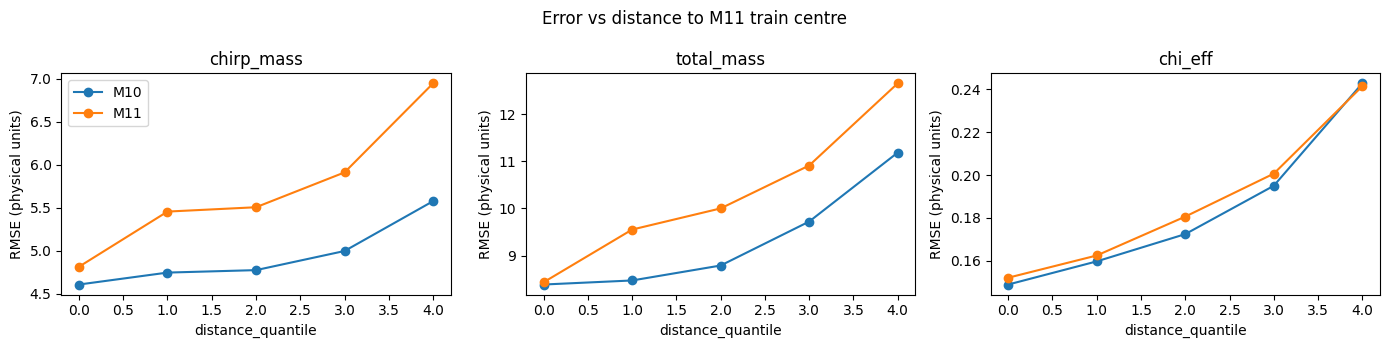

In [5]:
train_cov = np.cov(train_y,rowvar=False,ddof=1)
train_z = (train_y-train_mu)/train_sigma
scaled_cov = train_cov / np.outer(train_sigma,train_sigma)
rank = np.linalg.matrix_rank(scaled_cov)
precision = np.linalg.inv(scaled_cov) if rank==3 else np.linalg.pinv(scaled_cov, rcond=1e-12)
print("Reference=train_M11; covariance rank:",rank,"condition:",np.linalg.cond(scaled_cov))
def mahalanobis(values):
    z = (values-train_mu)/train_sigma
    squared = np.einsum("ni,ij,nj->n",z,precision,z)
    require((squared>=-1e-10).all(), "Invalid squared distance")
    return np.sqrt(np.maximum(squared,0))
centre_tables = []
for model,t in tests.items():
    t["d_M"] = mahalanobis(t["truth"])
    centre_tables.append(grouped_metrics(model,"distance_to_train_M11",{"distance_quantile":(t["d_M"],5)}))
centre_distance_metrics = pd.concat(centre_tables,ignore_index=True)
real["mahalanobis_distance"] = mahalanobis(real_coordinates)
real["mahalanobis_percentile"] = percentile(real.mahalanobis_distance,tests["M11"]["d_M"])
real["mahalanobis_percentile_vs_M10_test"] = percentile(real.mahalanobis_distance,tests["M10"]["d_M"])
real["training_reference"] = "M11 train only; common reference, not M10 own train"
display(centre_distance_metrics)
display(real)
binned_error_plot(centre_distance_metrics,"distance_quantile","Error vs distance to M11 train centre")

## 4. SNR y estratificación de masas

SNR sintético: `final_network_snr` en los IDs test M11, óptimo final 30–512 Hz.
SNR real: `network_snr_lvk`, de catálogo; no es la misma definición instrumental.
No asignar el SNR M11 a M10. Bins nominales [10,12.5),…,[22.5,25]; valores fuera
se cuentan explícitamente. Estratos de SNR/masa usan terciles, sin ajustar modelos.
Spearman sólo descriptivo en reales, con n y sin p-values ni afirmaciones fuertes.

M11 SNR outside nominal range: 0


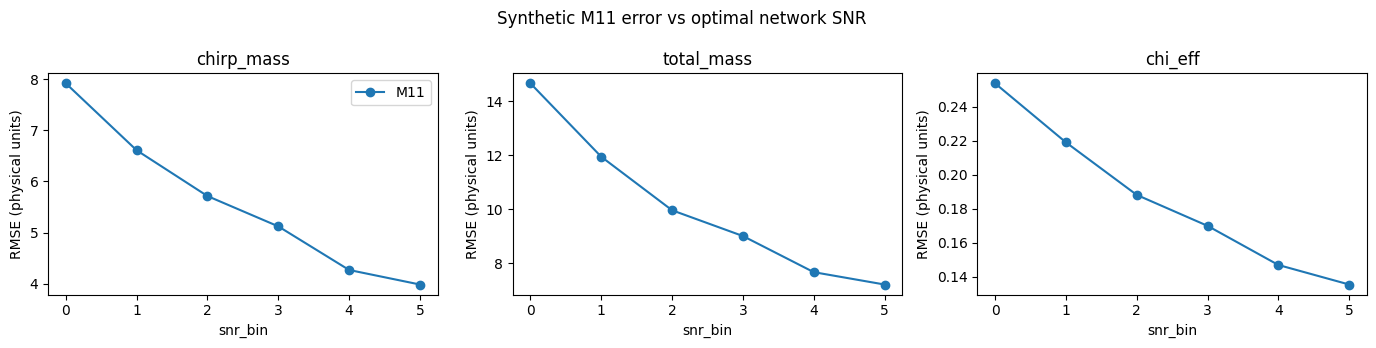

,event,chirp_mass_lvk,total_mass_lvk,chi_eff_lvk,network_snr_lvk,M10_chirp_mass_discrepancy,M10_total_mass_discrepancy,M10_chi_eff_discrepancy,M11_chirp_mass_discrepancy,M11_total_mass_discrepancy,M11_chi_eff_discrepancy,mahalanobis_distance,mahalanobis_percentile,mahalanobis_percentile_vs_M10_test,training_reference
8,GW200316_215756,10.6750,25.8640,0.13,10.3,1.832020,6.215116,0.058954,3.234145,9.231554,0.070907,2.250340,85.300000,85.536667,"M11 train only; common reference, not M10 own ..."
1,GW191230_180458,61.6850,145.3400,-0.05,10.4,12.305186,30.877622,0.340034,9.961835,20.912775,0.063014,1.479831,46.246667,46.506667,"M11 train only; common reference, not M10 own ..."
5,GW200219_094415,43.3320,102.0500,-0.08,10.7,4.502106,6.351077,0.498843,2.411392,3.873451,0.317714,0.625518,3.693333,3.680000,"M11 train only; common reference, not M10 own ..."
4,GW200208_130117,38.7800,91.4200,-0.07,10.8,8.780338,13.649156,0.307677,1.987950,2.932795,0.141535,0.653605,4.280000,4.246667,"M11 train only; common reference, not M10 own ..."
3,GW200202_154313,8.1641,19.1622,0.04,10.8,2.453911,8.691456,0.393547,6.999732,20.709270,0.126536,2.457296,90.910000,91.016667,"M11 train only; common reference, not M10 own ..."
0,GW191215_223052,24.8400,58.4550,-0.04,11.2,8.310353,18.257630,0.443656,1.621442,3.810551,0.337585,1.360725,38.546667,39.216667,"M11 train only; common reference, not M10 own ..."
7,GW200311_115853,32.7180,76.1370,-0.02,17.8,1.709157,6.348121,0.102605,1.824385,5.560659,0.057892,0.983158,17.013333,17.040000,"M11 train only; common reference, not M10 own ..."
6,GW200224_222234,41.0520,95.4360,0.10,20.0,2.103595,5.797085,0.072495,0.620746,0.506392,0.025975,0.754218,6.790000,6.753333,"M11 train only; common reference, not M10 own ..."
2,GW200129_065458,32.0960,74.6940,0.11,26.8,1.966104,3.248391,0.125243,0.854669,0.649025,0.087100,1.042137,19.986667,20.140000,"M11 train only; common reference, not M10 own ..."


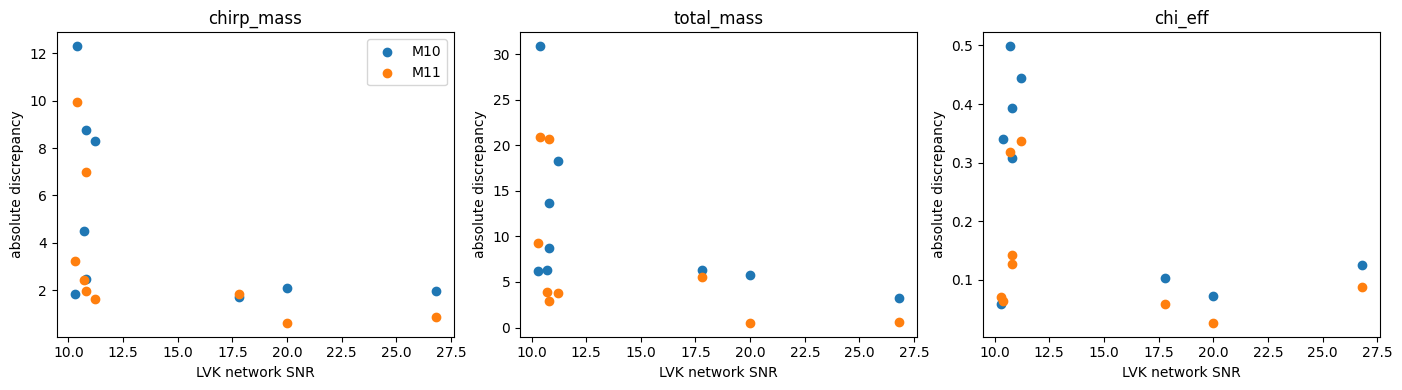

,model,label,n,spearman_rho
0,M10,chirp_mass,9,-0.343099
1,M11,chirp_mass,9,-0.861932
2,M10,total_mass,9,-0.493728
3,M11,total_mass,9,-0.728040
4,M10,chi_eff,9,-0.167365
5,M11,chi_eff,9,-0.192470


In [6]:
snr = np.asarray(metadata["final_network_snr"],dtype=float)
snr_edges = np.array([10,12.5,15,17.5,20,22.5,25])
print("M11 SNR outside nominal range:",int(((snr<10)|(snr>25)).sum()))
snr_rows = []
for b,(low,high) in enumerate(zip(snr_edges[:-1],snr_edges[1:])):
    mask = (snr>=low)&((snr<=high) if b==len(snr_edges)-2 else (snr<high))
    for j,label in enumerate(LABELS):
        snr_rows.append(dict(model="M11",label=label,snr_bin=b,snr_min=low,snr_max=high,
                            **error_metrics(tests["M11"]["residual"][mask,j])))
snr_summary = pd.DataFrame(snr_rows)
binned_error_plot(snr_summary,"snr_bin","Synthetic M11 error vs optimal network SNR")
strata_tables = []
for j,mass_label in enumerate(LABELS[:2]):
    strata_tables.append(grouped_metrics("M11",f"mass_within_snr_{mass_label}",
        {"mass_quantile":(tests["M11"]["truth"][:,j],5),"snr_stratum":(snr,3)}))
    strata_tables.append(grouped_metrics("M11",f"snr_within_mass_{mass_label}",
        {"snr_quantile":(snr,5),"mass_stratum":(tests["M11"]["truth"][:,j],3)}))
real_snr_table = real.sort_values("network_snr_lvk")
display(real_snr_table)
correlation_rows = []
fig,axes = plt.subplots(1,3,figsize=(14,4))
for ax,label in zip(axes,LABELS):
    for model in tests:
        col = f"{model}_{label}_discrepancy"
        valid = real[["network_snr_lvk",col]].dropna()
        rho = (spearmanr(valid.network_snr_lvk,valid[col]).statistic
               if len(valid)>=3 and valid.network_snr_lvk.nunique()>1 and valid[col].nunique()>1 else np.nan)
        correlation_rows.append(dict(model=model,label=label,n=len(valid),spearman_rho=rho))
        ax.scatter(valid.network_snr_lvk,valid[col],label=model)
    ax.set(title=label,xlabel="LVK network SNR",ylabel="absolute discrepancy")
axes[0].legend();fig.tight_layout();plt.show()
spearman_summary = pd.DataFrame(correlation_rows)
display(spearman_summary)

## 5. Densidad local en labels — train_M11, k=50

NearestNeighbors únicamente en las tres coordenadas de labels estandarizadas con
train_M11. Se ajusta una vez; consultas por bloques para no retener matrices grandes.
k=20 y k=100 son sólo controles de robustez de k=50, no se elige k mirando resultados.
Un radio mayor indica menor densidad local; no es una probabilidad calibrada.
Los puntos test no forman parte del train de referencia. No se usan embeddings ni KDE.

,model,analysis,label,density_quantile,density_quantile_min,density_quantile_max,n,sufficient_count,RMSE,MAE,bias,median_residual,p16,p84,k
0,M10,label_density_train_M11_k20,chirp_mass,0,0.018691,0.033363,6000,True,5.139823,3.724566,-2.553597,-1.997156,-6.326720,1.262052,20
1,M10,label_density_train_M11_k20,total_mass,0,0.018691,0.033363,6000,True,9.624975,7.255103,-2.568009,-1.733379,-10.992136,5.727924,20
2,M10,label_density_train_M11_k20,chi_eff,0,0.018691,0.033363,6000,True,0.161768,0.123184,-0.023172,-0.016099,-0.168534,0.122978,20
3,M10,label_density_train_M11_k20,chirp_mass,1,0.033364,0.041234,6000,True,4.315860,3.063125,-0.669887,-0.022282,-4.279484,2.670037,20
4,M10,label_density_train_M11_k20,total_mass,1,0.033364,0.041234,6000,True,9.192504,6.976302,1.182054,1.977027,-7.064604,8.949316,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,M11,label_density_train_M11_k100,total_mass,3,0.087434,0.106714,6000,True,9.573352,6.876915,2.545223,2.586706,-4.713547,9.855067,100
86,M11,label_density_train_M11_k100,chi_eff,3,0.087434,0.106714,6000,True,0.193139,0.144659,0.015295,0.015851,-0.156142,0.184811,100
87,M11,label_density_train_M11_k100,chirp_mass,4,0.106720,0.368725,6000,True,6.915156,4.453679,2.774075,1.891811,-1.186270,6.939065,100
88,M11,label_density_train_M11_k100,total_mass,4,0.106720,0.368725,6000,True,11.453655,7.963515,1.521001,1.642436,-7.126771,9.985667,100


,event,chirp_mass_lvk,total_mass_lvk,chi_eff_lvk,network_snr_lvk,M10_chirp_mass_discrepancy,M10_total_mass_discrepancy,M10_chi_eff_discrepancy,M11_chirp_mass_discrepancy,M11_total_mass_discrepancy,M11_chi_eff_discrepancy,mahalanobis_distance,mahalanobis_percentile,mahalanobis_percentile_vs_M10_test,training_reference,r20,r50,r100,density_percentile,density_percentile_vs_M10_test
0,GW191215_223052,24.8400,58.4550,-0.04,11.2,8.310353,18.257630,0.443656,1.621442,3.810551,0.337585,1.360725,38.546667,39.216667,"M11 train only; common reference, not M10 own ...",0.031890,0.043418,0.058222,11.813333,11.643333
1,GW191230_180458,61.6850,145.3400,-0.05,10.4,12.305186,30.877622,0.340034,9.961835,20.912775,0.063014,1.479831,46.246667,46.506667,"M11 train only; common reference, not M10 own ...",0.040263,0.048975,0.061092,23.413333,23.630000
2,GW200129_065458,32.0960,74.6940,0.11,26.8,1.966104,3.248391,0.125243,0.854669,0.649025,0.087100,1.042137,19.986667,20.140000,"M11 train only; common reference, not M10 own ...",0.032571,0.043817,0.056899,12.676667,12.480000
3,GW200202_154313,8.1641,19.1622,0.04,10.8,2.453911,8.691456,0.393547,6.999732,20.709270,0.126536,2.457296,90.910000,91.016667,"M11 train only; common reference, not M10 own ...",0.048285,0.063789,0.086984,51.780000,51.763333
4,GW200208_130117,38.7800,91.4200,-0.07,10.8,8.780338,13.649156,0.307677,1.987950,2.932795,0.141535,0.653605,4.280000,4.246667,"M11 train only; common reference, not M10 own ...",0.030840,0.043351,0.052371,11.710000,11.486667
5,GW200219_094415,43.3320,102.0500,-0.08,10.7,4.502106,6.351077,0.498843,2.411392,3.873451,0.317714,0.625518,3.693333,3.680000,"M11 train only; common reference, not M10 own ...",0.032584,0.045413,0.055293,16.030000,16.006667
6,GW200224_222234,41.0520,95.4360,0.10,20.0,2.103595,5.797085,0.072495,0.620746,0.506392,0.025975,0.754218,6.790000,6.753333,"M11 train only; common reference, not M10 own ...",0.027872,0.037859,0.050927,2.333333,2.340000
7,GW200311_115853,32.7180,76.1370,-0.02,17.8,1.709157,6.348121,0.102605,1.824385,5.560659,0.057892,0.983158,17.013333,17.040000,"M11 train only; common reference, not M10 own ...",0.028950,0.042747,0.055488,10.440000,10.190000
8,GW200316_215756,10.6750,25.8640,0.13,10.3,1.832020,6.215116,0.058954,3.234145,9.231554,0.070907,2.250340,85.300000,85.536667,"M11 train only; common reference, not M10 own ...",0.038237,0.057141,0.073300,39.840000,39.643333


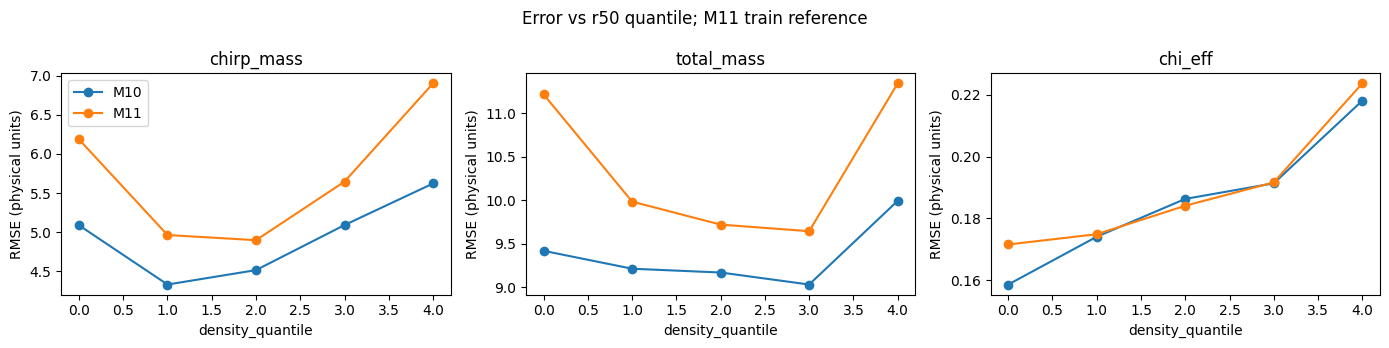

In [7]:
neighbors = NearestNeighbors(n_neighbors=100, algorithm="kd_tree", metric="euclidean", n_jobs=1)
neighbors.fit(train_z)
def density_radii(values):
    z = (values-train_mu)/train_sigma
    radii = np.empty((len(z),3))
    for start in range(0,len(z),2048):
        distances,_ = neighbors.kneighbors(z[start:start+2048],n_neighbors=100)
        radii[start:start+2048] = distances[:,[19,49,99]]
    return radii

density_tables = []
for model,t in tests.items():
    t["radii"] = density_radii(t["truth"])
    for j,k in enumerate((20,50,100)):
        table = grouped_metrics(model,f"label_density_train_M11_k{k}",{"density_quantile":(t["radii"][:,j],5)})
        table["k"] = k;density_tables.append(table)
    for j,mass_label in enumerate(LABELS[:2]):
        strata_tables.append(grouped_metrics(model,f"density_within_mass_{mass_label}",
            {"density_quantile":(t["radii"][:,1],5),"mass_stratum":(t["truth"][:,j],3)}))
density_diagnostics = pd.concat(density_tables,ignore_index=True)
real_radii = density_radii(real_coordinates)
for j,k in enumerate((20,50,100)):
    real[f"r{k}"] = real_radii[:,j]
real["density_percentile"] = percentile(real.r50,tests["M11"]["radii"][:,1])
real["density_percentile_vs_M10_test"] = percentile(real.r50,tests["M10"]["radii"][:,1])
display(density_diagnostics)
display(real)
binned_error_plot(density_diagnostics[density_diagnostics.k==50],"density_quantile","Error vs r50 quantile; M11 train reference")

## 6. Duración / truncación / baja masa — M11

Se usa el campo guardado `full_network_duration`, no una duración reconstruida desde
strain. `is_truncated` es el indicador de generación, no un veto nuevo. Conservar
conteos incluso cuando un grupo es vacío o pequeño; no inventar comparación si todos
los ejemplos pertenecen al mismo grupo. Se condiciona por SNR y masa para describir
confusión entre variables; condicionamiento no equivale a demostrar causalidad.

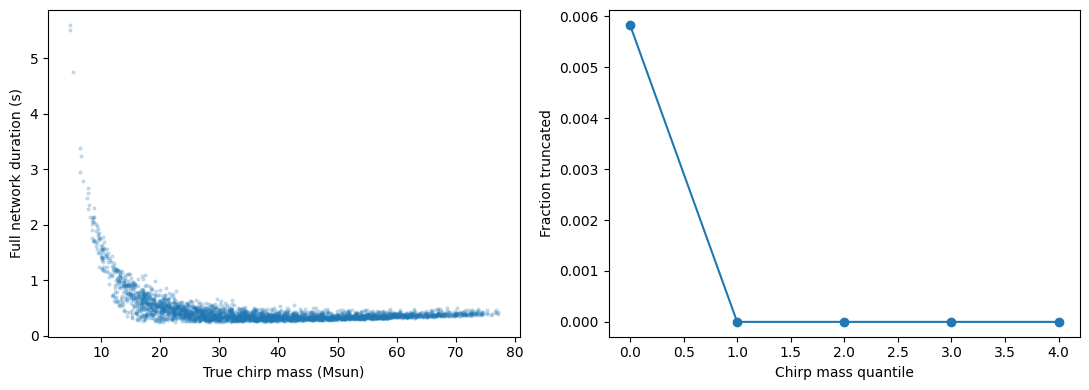

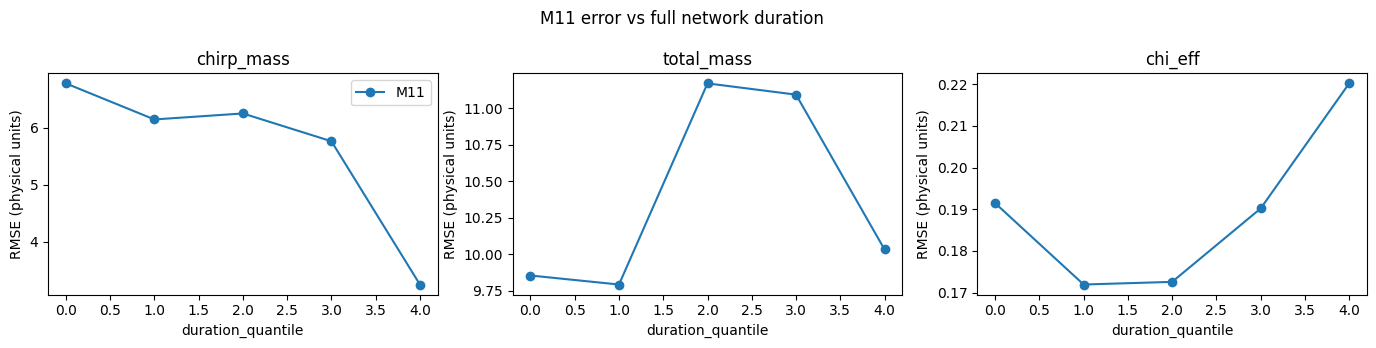

,model,analysis,label,duration_quantile,duration_quantile_min,duration_quantile_max,n,sufficient_count,RMSE,MAE,bias,median_residual,p16,p84,mass_quantile,mass_min,mass_max,truncated_fraction,is_truncated
0,M11,error_vs_duration,chirp_mass,0.0,0.247803,0.316406,5993,True,6.774653,4.817023,1.958433,1.296069,-3.264330,7.454017,NaN,NaN,NaN,NaN,NaN
1,M11,error_vs_duration,total_mass,0.0,0.247803,0.316406,5993,True,9.855525,7.272281,3.623821,3.279078,-4.001924,11.482503,NaN,NaN,NaN,NaN,NaN
2,M11,error_vs_duration,chi_eff,0.0,0.247803,0.316406,5993,True,0.191469,0.149261,0.085967,0.078480,-0.080141,0.249448,NaN,NaN,NaN,NaN,NaN
3,M11,error_vs_duration,chirp_mass,1.0,0.316650,0.351074,5987,True,6.143117,4.376950,-0.297251,-0.309058,-5.174220,4.588814,NaN,NaN,NaN,NaN,NaN
4,M11,error_vs_duration,total_mass,1.0,0.316650,0.351074,5987,True,9.793726,7.103976,-0.195024,0.095626,-8.471610,8.030857,NaN,NaN,NaN,NaN,NaN
5,M11,error_vs_duration,chi_eff,1.0,0.316650,0.351074,5987,True,0.171957,0.132090,0.005818,0.002078,-0.151503,0.164345,NaN,NaN,NaN,NaN,NaN
6,M11,error_vs_duration,chirp_mass,2.0,0.351318,0.393066,6006,True,6.247903,4.346355,-1.535295,-1.294909,-6.171007,3.165502,NaN,NaN,NaN,NaN,NaN
7,M11,error_vs_duration,total_mass,2.0,0.351318,0.393066,6006,True,11.171322,7.791063,-2.860545,-2.008133,-11.467750,5.912804,NaN,NaN,NaN,NaN,NaN
8,M11,error_vs_duration,chi_eff,2.0,0.351318,0.393066,6006,True,0.172593,0.130127,-0.037614,-0.035822,-0.183785,0.113729,NaN,NaN,NaN,NaN,NaN
9,M11,error_vs_duration,chirp_mass,3.0,0.393311,0.496826,6009,True,5.761130,3.881181,-1.119105,-0.272344,-5.763788,3.044342,NaN,NaN,NaN,NaN,NaN


In [8]:
duration = np.asarray(metadata["full_network_duration"],dtype=float)
truncated_raw = np.asarray(metadata["is_truncated"])
require(np.isin(truncated_raw,[0,1]).all(), "Unexpected truncation encoding")
truncated = truncated_raw.astype(bool)
chirp = tests["M11"]["truth"][:,0]
duration_metrics = grouped_metrics("M11","error_vs_duration",{"duration_quantile":(duration,5)})
truncation_rows = []
mass_bins = quantile_bins(chirp,5)
for b in np.unique(mass_bins):
    mask = mass_bins==b
    truncation_rows.append(dict(analysis="truncated_fraction_by_chirp_mass",mass_quantile=int(b),
        mass_min=chirp[mask].min(),mass_max=chirp[mask].max(),n=int(mask.sum()),
        truncated_fraction=float(truncated[mask].mean())))
for state in (False,True):
    for j,label in enumerate(LABELS):
        truncation_rows.append(dict(analysis="error_by_truncation",model="M11",label=label,
            is_truncated=state,**error_metrics(tests["M11"]["residual"][truncated==state,j])))
duration_diagnostics = pd.concat([duration_metrics,pd.DataFrame(truncation_rows)],ignore_index=True)
for j,mass_label in enumerate(LABELS[:2]):
    strata_tables.append(grouped_metrics("M11",f"duration_conditioned_on_snr_mass_{mass_label}",
        {"duration_quantile":(duration,3),"snr_stratum":(snr,3),"mass_stratum":(tests["M11"]["truth"][:,j],3)}))
fig,axes = plt.subplots(1,2,figsize=(11,4))
axes[0].scatter(chirp[::SCATTER_STEP],duration[::SCATTER_STEP],s=4,alpha=.2)
axes[0].set(xlabel="True chirp mass (Msun)",ylabel="Full network duration (s)")
fractions = pd.DataFrame(truncation_rows).query("analysis == 'truncated_fraction_by_chirp_mass'")
axes[1].plot(fractions.mass_quantile,fractions.truncated_fraction,"o-")
axes[1].set(xlabel="Chirp mass quantile",ylabel="Fraction truncated")
fig.tight_layout();plt.show()
binned_error_plot(duration_metrics,"duration_quantile","M11 error vs full network duration")
display(duration_diagnostics)

## 7. Tabla real combinada

Distancias respecto a train_M11, percentiles principales respecto a test_M11.
Se adjuntan percentiles alternativos respecto a test_M10 para transparencia, siempre
con la misma referencia train_M11. Las discrepancias son absolutas respecto a LVK,
no errores contra verdad conocida. No se asigna duración/truncación sintética a reales.

In [9]:
real_event_diagnostics = real.sort_values("chirp_mass_lvk").reset_index(drop=True)
display(real_event_diagnostics)

,event,chirp_mass_lvk,total_mass_lvk,chi_eff_lvk,network_snr_lvk,M10_chirp_mass_discrepancy,M10_total_mass_discrepancy,M10_chi_eff_discrepancy,M11_chirp_mass_discrepancy,M11_total_mass_discrepancy,M11_chi_eff_discrepancy,mahalanobis_distance,mahalanobis_percentile,mahalanobis_percentile_vs_M10_test,training_reference,r20,r50,r100,density_percentile,density_percentile_vs_M10_test
0,GW200202_154313,8.1641,19.1622,0.04,10.8,2.453911,8.691456,0.393547,6.999732,20.709270,0.126536,2.457296,90.910000,91.016667,"M11 train only; common reference, not M10 own ...",0.048285,0.063789,0.086984,51.780000,51.763333
1,GW200316_215756,10.6750,25.8640,0.13,10.3,1.832020,6.215116,0.058954,3.234145,9.231554,0.070907,2.250340,85.300000,85.536667,"M11 train only; common reference, not M10 own ...",0.038237,0.057141,0.073300,39.840000,39.643333
2,GW191215_223052,24.8400,58.4550,-0.04,11.2,8.310353,18.257630,0.443656,1.621442,3.810551,0.337585,1.360725,38.546667,39.216667,"M11 train only; common reference, not M10 own ...",0.031890,0.043418,0.058222,11.813333,11.643333
3,GW200129_065458,32.0960,74.6940,0.11,26.8,1.966104,3.248391,0.125243,0.854669,0.649025,0.087100,1.042137,19.986667,20.140000,"M11 train only; common reference, not M10 own ...",0.032571,0.043817,0.056899,12.676667,12.480000
4,GW200311_115853,32.7180,76.1370,-0.02,17.8,1.709157,6.348121,0.102605,1.824385,5.560659,0.057892,0.983158,17.013333,17.040000,"M11 train only; common reference, not M10 own ...",0.028950,0.042747,0.055488,10.440000,10.190000
5,GW200208_130117,38.7800,91.4200,-0.07,10.8,8.780338,13.649156,0.307677,1.987950,2.932795,0.141535,0.653605,4.280000,4.246667,"M11 train only; common reference, not M10 own ...",0.030840,0.043351,0.052371,11.710000,11.486667
6,GW200224_222234,41.0520,95.4360,0.10,20.0,2.103595,5.797085,0.072495,0.620746,0.506392,0.025975,0.754218,6.790000,6.753333,"M11 train only; common reference, not M10 own ...",0.027872,0.037859,0.050927,2.333333,2.340000
7,GW200219_094415,43.3320,102.0500,-0.08,10.7,4.502106,6.351077,0.498843,2.411392,3.873451,0.317714,0.625518,3.693333,3.680000,"M11 train only; common reference, not M10 own ...",0.032584,0.045413,0.055293,16.030000,16.006667
8,GW191230_180458,61.6850,145.3400,-0.05,10.4,12.305186,30.877622,0.340034,9.961835,20.912775,0.063014,1.479831,46.246667,46.506667,"M11 train only; common reference, not M10 own ...",0.040263,0.048975,0.061092,23.413333,23.630000


## 8. Síntesis estratificada

Tablas completas con límites físicos y n por estrato. Para las preguntas clave:
- Baja masa a SNR alto: `mass_within_snr_*`, menor mass_quantile y mayor snr_stratum.
- SNR bajo a masas intermedias: `snr_within_mass_*`, menor snr_quantile y mass_stratum central.
- Menor densidad condicionando masa: `density_within_mass_*`, comparar density_quantile dentro de cada mass_stratum.
- Duración larga condicionando SNR/masa: `duration_conditioned_on_snr_mass_*`, comparar duration_quantile manteniendo ambos estratos.

Revisar todos los estratos y no sólo esquinas seleccionadas. Los bins conjuntos
sin soporte no aparecen; los de n<30 conservan n pero métricas NaN. Los cuantiles
pueden colapsar si hay empates. No extrapolar respuestas M11 al SNR de M10.

In [10]:
stratified_summary = pd.concat(strata_tables,ignore_index=True)
display(stratified_summary)
for analysis,table in stratified_summary.groupby("analysis",sort=False):
    print(analysis)
    dimensions = [c for c in ["mass_quantile","snr_quantile","density_quantile","duration_quantile",
                             "mass_stratum","snr_stratum"] if c in table and table[c].notna().any()]
    display(table[["model","label",*dimensions,"n","RMSE","MAE","bias","median_residual"]])

,model,analysis,label,mass_quantile,snr_stratum,mass_quantile_min,mass_quantile_max,snr_stratum_min,snr_stratum_max,n,...,snr_quantile_min,snr_quantile_max,mass_stratum_min,mass_stratum_max,density_quantile,density_quantile_min,density_quantile_max,duration_quantile,duration_quantile_min,duration_quantile_max
0,M11,mass_within_snr_chirp_mass,chirp_mass,0.0,0.0,4.950011,21.392399,10.001520,14.966086,1967,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,M11,mass_within_snr_chirp_mass,total_mass,0.0,0.0,4.950011,21.392399,10.001520,14.966086,1967,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,M11,mass_within_snr_chirp_mass,chi_eff,0.0,0.0,4.950011,21.392399,10.001520,14.966086,1967,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,M11,mass_within_snr_chirp_mass,chirp_mass,0.0,1.0,4.498729,21.393256,14.972377,20.006603,2030,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,M11,mass_within_snr_chirp_mass,total_mass,0.0,1.0,4.498729,21.393256,14.972377,20.006603,2030,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517,M11,duration_conditioned_on_snr_mass_total_mass,total_mass,NaN,2.0,NaN,NaN,20.011023,24.995011,683,...,NaN,NaN,79.603042,110.327293,NaN,NaN,NaN,2.0,0.413818,1.149414
518,M11,duration_conditioned_on_snr_mass_total_mass,chi_eff,NaN,2.0,NaN,NaN,20.011023,24.995011,683,...,NaN,NaN,79.603042,110.327293,NaN,NaN,NaN,2.0,0.413818,1.149414
519,M11,duration_conditioned_on_snr_mass_total_mass,chirp_mass,NaN,2.0,NaN,NaN,20.046477,24.982460,375,...,NaN,NaN,110.431869,178.839463,NaN,NaN,NaN,2.0,0.413818,0.572754
520,M11,duration_conditioned_on_snr_mass_total_mass,total_mass,NaN,2.0,NaN,NaN,20.046477,24.982460,375,...,NaN,NaN,110.431869,178.839463,NaN,NaN,NaN,2.0,0.413818,0.572754


mass_within_snr_chirp_mass


,model,label,mass_quantile,snr_stratum,n,RMSE,MAE,bias,median_residual
0,M11,chirp_mass,0.0,0.0,1967,6.660833,4.106612,3.878884,2.411010
1,M11,total_mass,0.0,0.0,1967,13.896666,10.049991,5.778522,5.931702
2,M11,chi_eff,0.0,0.0,1967,0.291656,0.222100,0.026679,0.022383
3,M11,chirp_mass,0.0,1.0,2030,3.893914,2.588752,2.481216,1.931530
4,M11,total_mass,0.0,1.0,2030,8.832711,6.767446,4.446881,4.737912
5,M11,chi_eff,0.0,1.0,2030,0.216915,0.161084,0.010521,0.005307
6,M11,chirp_mass,0.0,2.0,2003,3.043236,2.110873,2.054041,1.767018
7,M11,total_mass,0.0,2.0,2003,7.854003,5.718491,3.932752,4.460787
8,M11,chi_eff,0.0,2.0,2003,0.165969,0.123261,0.009564,-0.000579
9,M11,chirp_mass,1.0,0.0,2037,6.966453,4.643882,3.509953,2.184655


snr_within_mass_chirp_mass


,model,label,snr_quantile,mass_stratum,n,RMSE,MAE,bias,median_residual
45,M11,chirp_mass,0.0,0.0,1988,7.465292,4.781598,4.178666,2.604010
46,M11,total_mass,0.0,0.0,1988,14.440390,10.510995,6.520539,6.254654
47,M11,chi_eff,0.0,0.0,1988,0.282958,0.218208,0.042654,0.043884
48,M11,chirp_mass,0.0,1.0,2045,6.395560,4.648915,1.180119,0.725654
49,M11,total_mass,0.0,1.0,2045,11.493850,8.543018,2.054101,2.105607
50,M11,chi_eff,0.0,1.0,2045,0.211996,0.164002,-0.012218,-0.012251
51,M11,chirp_mass,0.0,2.0,1967,9.290664,6.903872,-5.369914,-4.767233
52,M11,total_mass,0.0,2.0,1967,16.997549,12.442384,-9.019717,-8.168707
53,M11,chi_eff,0.0,2.0,1967,0.250633,0.201226,-0.066045,-0.081562
54,M11,chirp_mass,1.0,0.0,2041,5.658870,3.571316,3.140131,2.082358


...

,model,label,density_quantile,mass_stratum,n,RMSE,MAE,bias,median_residual
225,M10,chirp_mass,0.0,0.0,714,2.407147,1.791881,0.199947,0.272501
226,M10,total_mass,0.0,0.0,714,7.112596,5.261540,3.915852,3.388932
227,M10,chi_eff,0.0,0.0,714,0.155366,0.119279,0.013675,0.010642
228,M10,chirp_mass,0.0,1.0,1507,3.976962,2.923029,-1.266882,-1.032551
229,M10,total_mass,0.0,1.0,1507,7.734775,5.835295,1.088161,1.185474
...,...,...,...,...,...,...,...,...,...
355,M11,total_mass,4.0,1.0,2704,11.194656,7.886074,1.518237,0.984090
356,M11,chi_eff,4.0,1.0,2704,0.189508,0.142191,0.009102,-0.004651
357,M11,chirp_mass,4.0,2.0,625,8.697960,6.572826,-1.585486,-1.997000
358,M11,total_mass,4.0,2.0,625,15.710225,11.390806,-4.819162,-4.547998


duration_conditioned_on_snr_mass_chirp_mass


,model,label,duration_quantile,mass_stratum,snr_stratum,n,RMSE,MAE,bias,median_residual
360,M11,chirp_mass,0.0,0.0,0.0,428,12.407901,9.745978,9.255973,7.540186
361,M11,total_mass,0.0,0.0,0.0,428,15.561679,12.469046,11.271147,10.120664
362,M11,chi_eff,0.0,0.0,0.0,428,0.258437,0.205320,0.163410,0.152454
363,M11,chirp_mass,0.0,1.0,0.0,1747,6.837118,5.016298,2.216773,1.662561
364,M11,total_mass,0.0,1.0,0.0,1747,11.046780,8.305797,4.231341,4.082985
...,...,...,...,...,...,...,...,...,...,...
436,M11,total_mass,2.0,1.0,2.0,555,4.830999,3.843896,-0.411621,-0.264642
437,M11,chi_eff,2.0,1.0,2.0,555,0.130118,0.105902,-0.055151,-0.058028
438,M11,chirp_mass,2.0,2.0,2.0,346,6.406660,4.865463,-4.610086,-4.104848
439,M11,total_mass,2.0,2.0,2.0,346,12.574040,9.472061,-9.112450,-8.484328


duration_conditioned_on_snr_mass_total_mass


,model,label,duration_quantile,mass_stratum,snr_stratum,n,RMSE,MAE,bias,median_residual
441,M11,chirp_mass,0.0,0.0,0.0,450,6.843908,4.978509,3.809052,2.987038
442,M11,total_mass,0.0,0.0,0.0,450,12.440145,9.603014,8.688006,7.720234
443,M11,chi_eff,0.0,0.0,0.0,450,0.254618,0.201383,0.163182,0.148814
444,M11,chirp_mass,0.0,1.0,0.0,1766,8.310446,5.931915,2.808002,1.809646
445,M11,total_mass,0.0,1.0,0.0,1766,11.784755,8.784641,4.153010,3.814850
...,...,...,...,...,...,...,...,...,...,...
517,M11,total_mass,2.0,1.0,2.0,683,5.502639,3.932080,-1.170817,-0.938298
518,M11,chi_eff,2.0,1.0,2.0,683,0.121799,0.092458,-0.047456,-0.043938
519,M11,chirp_mass,2.0,2.0,2.0,375,6.211528,4.634338,-4.329219,-3.972441
520,M11,total_mass,2.0,2.0,2.0,375,12.267347,9.255592,-8.889181,-8.302426


## 9. Guardar sólo tablas compactas

In [11]:
OUTPUT_DIR.mkdir(parents=True,exist_ok=True)
outputs = {
    "distribution_summary":distribution_summary,
    "centre_distance_metrics":centre_distance_metrics,
    "real_event_diagnostics":real_event_diagnostics,
    "density_diagnostics":density_diagnostics,
    "duration_diagnostics":duration_diagnostics,
    "stratified_summary":stratified_summary,
    "residual_vs_z_summary":regression_summary,
    "snr_metrics":snr_summary,
    "real_snr_spearman":spearman_summary,
}
for name,table in outputs.items():
    table.to_csv(OUTPUT_DIR/f"{name}.csv",index=False)
print("Compact tables saved:",OUTPUT_DIR)

Compact tables saved: /data/vserrano/cbc_pe_data/results/M11_final_G1_500k/M11_15_result_interpretation


## 10. Interpretation of M11 performance and remaining hypotheses

This notebook was designed to understand *why* the final M11 model behaves differently from M10, with particular attention to the low-mass failures observed in the real-event study. The analysis was intentionally restricted to frozen predictions and metadata already available from the final M10/M11 pipelines; no retraining, new inference, or modification of the predictors was performed.

The main variables investigated were:

1. compression of the predicted target distributions and regression to the mean;
2. position of each sample relative to the center of the training distribution;
3. signal-to-noise ratio;
4. local label-space density;
5. signal duration and truncation.

The resulting picture is more informative than any single-variable explanation.

### 10.1 Regression to the mean is present in both models and is stronger in M11

For each physical target,

$$
z_j = \frac{y_j-\mu_{j,\mathrm{train}}}{\sigma_{j,\mathrm{train}}},
$$

measures the position of a true value relative to the center and scale of the corresponding training distribution.

The residual

$$
\epsilon_j = \hat y_j-y_j
$$

was analyzed as a function of \(z_j\) using ten approximately equipopulated quantile bins, with about 3000 test samples per bin.

A consistent pattern is observed:

$$
z_j < 0
\quad\Rightarrow\quad
\epsilon_j > 0,
$$

while

$$
z_j > 0
\quad\Rightarrow\quad
\epsilon_j < 0.
$$

Therefore, low values tend to be overpredicted and high values underpredicted. This is the expected signature of regression toward the center of the training distribution.

The same behavior is also visible in the compression of the prediction distributions. The ratios

$$
C_j = \frac{\sigma(\hat y_j)}{\sigma(y_j)}
$$

are below unity for all parameters:

| Parameter | M10 | M11 |
|---|---:|---:|
| chirp mass | 0.931 | 0.892 |
| total mass | 0.921 | 0.904 |
| \(\chi_{\mathrm{eff}}\) | 0.897 | 0.866 |

Thus, M11 produces a somewhat more compressed output distribution than M10.

This difference is particularly visible at the edges of the chirp-mass distribution. In the lowest chirp-mass decile, the mean bias changes from approximately

$$
+1.99\,M_\odot
$$

for M10 to

$$
+2.78\,M_\odot
$$

for M11. At the highest chirp-mass decile the corresponding biases are approximately

$$
-4.26\,M_\odot
$$

and

$$
-5.11\,M_\odot.
$$

Therefore, part of the low- and high-mass behavior observed in real events is already present in the synthetic test domain and is not exclusively a real-data effect.

---

### 10.2 Error increases away from the center of the joint training distribution

Marginal \(z\)-scores describe one target at a time. To characterize how unusual a complete parameter combination is, the analysis also uses the Mahalanobis distance in the three-dimensional label space

$$
\mathbf y =
(\mathcal M,\,M_{\mathrm{tot}},\,\chi_{\mathrm{eff}}).
$$

After centering and scaling using the M11 training set, the covariance matrix

$$
\Sigma
$$

captures not only the variance of each parameter but also correlations between them, particularly the strong relation between chirp mass and total mass.

The distance is

$$
d_M =
\sqrt{
(\mathbf y-\boldsymbol\mu)^T
\Sigma^{-1}
(\mathbf y-\boldsymbol\mu)
}.
$$

Unlike an ordinary Euclidean distance, \(d_M\) does not penalize equally in all directions: displacement along a direction of large natural variance or strong parameter correlation contributes less than displacement perpendicular to the populated training manifold.

The synthetic test samples were divided into five equipopulated bins in \(d_M\), with approximately 6000 samples per bin.

For M11, the RMSE increases systematically with distance from the training center.

For chirp mass:

$$
4.81
\rightarrow
5.45
\rightarrow
5.50
\rightarrow
5.91
\rightarrow
6.95\,M_\odot.
$$

For total mass:

$$
8.43
\rightarrow
9.55
\rightarrow
10.00
\rightarrow
10.91
\rightarrow
12.66\,M_\odot.
$$

For \(\chi_{\mathrm{eff}}\):

$$
0.152
\rightarrow
0.162
\rightarrow
0.181
\rightarrow
0.201
\rightarrow
0.241.
$$

This provides direct evidence that prediction difficulty increases for parameter combinations that are globally more peripheral with respect to the training distribution.

The real-event diagnostics are particularly informative. The two lowest-mass events are also the two most peripheral events according to the Mahalanobis percentile:

| Event | Mahalanobis percentile |
|---|---:|
| GW200202_154313 | 90.9% |
| GW200316_215756 | 85.3% |
| GW191230_180458 | 46.2% |
| GW191215_223052 | 38.5% |
| GW200129_065458 | 20.0% |
| GW200311_115853 | 17.0% |
| GW200224_222234 | 6.8% |
| GW200208_130117 | 4.3% |
| GW200219_094415 | 3.7% |

This is consistent with the large low-mass discrepancies observed for GW200202_154313 and GW200316_215756.

However, Mahalanobis distance should not be interpreted as a complete measure of prediction difficulty. For example, GW191230_180458 has very high masses and remains difficult for M11, but its Mahalanobis percentile is only approximately 46%. This illustrates why marginal target position, global joint distance, SNR, and local density provide complementary information rather than interchangeable diagnostics.

---

### 10.3 Low SNR increases prediction difficulty but does not explain the real-event failures by itself

The final M11 synthetic dataset contains the network SNR used during generation, while the real-event table contains the published LVK network SNR.

The synthetic analysis shows a strong dependence of prediction accuracy on SNR.

For the lowest chirp-mass quintile, for example, the chirp-mass RMSE changes from approximately

$$
6.66\,M_\odot
$$

for SNR $\sim 10-15$, to

$$
3.89\,M_\odot
$$

for SNR $\sim 15-20$, and

$$
3.04\,M_\odot
$$

for SNR $\sim 20-25$.

Total-mass and $\chi_{\mathrm{eff}}$ errors show the same qualitative improvement as SNR increases.

Therefore, low SNR clearly reduces the amount of information available to the network and amplifies prediction errors.

However, the real-event results show that low SNR is not sufficient to explain a bad prediction.

For example:

- GW200202_154313 has LVK network SNR $10.8$ and is difficult for M11;
- GW200316_215756 has SNR $10.3$ and is also difficult;
- GW200208_130117 has SNR $10.8$ but is predicted much more accurately;
- GW200219_094415 has SNR $10.7$ and does not display the same low-mass failure;
- GW191215_223052 has SNR $11.2$ and M11 substantially improves over M10.

The descriptive Spearman correlations for M11 are

$$
\rho_s \approx -0.86
$$

for chirp-mass discrepancy,

$$
\rho_s \approx -0.73
$$

for total-mass discrepancy, and

$$
\rho_s \approx -0.19
$$

for $\chi_{\mathrm{eff}}$.

Because only nine real events are available, these values should be interpreted descriptively rather than as strong inferential evidence.

The combined synthetic and real results support the interpretation that SNR acts as a **difficulty modulator**, rather than as the unique cause of the low-mass failures.

A more appropriate qualitative picture is therefore

$$
\mathrm{difficulty}
\sim
\mathrm{position\ in\ parameter\ space}
\times
\mathrm{SNR},
$$

rather than

$$
\mathrm{difficulty}
\sim
\mathrm{SNR}
$$

alone.

No direct real-data equivalent of the exact simulation optimal SNR is currently used here. Constructing one would require choosing an estimated waveform, for example from LVK posterior parameters, projecting it into the detectors and evaluating it against the corresponding PSD. Such a quantity would be model dependent and is not required to establish the conclusions above.

---

### 10.4 Local label-space density does not explain the two low-mass failures

A separate question is whether difficult events simply fall in regions where the training set contains very few neighboring examples.

To test this, the training labels were standardized and a nearest-neighbor distance was computed in the three-dimensional label space. The principal diagnostic is

$$
r_{50},
$$

the distance to the 50th nearest training example. Results for $k=20$ and $k=100$ were also computed as robustness checks.

Small $r_k$ corresponds to a locally dense region, whereas large $r_k$ indicates a sparse region.

The so-called density quantiles are therefore more precisely interpreted as **local sparsity quantiles**:

- low quantile: locally dense training region;
- high quantile: locally sparse training region.

For real events, the density percentile indicates where the event's $r_{50}$ lies relative to the synthetic test distribution.

The two problematic low-mass events have

$$
P_{\mathrm{density}}(\mathrm{GW200202})
\simeq 51.8\%,
$$

and

$$
P_{\mathrm{density}}(\mathrm{GW200316})
\simeq 39.8\%.
$$

These are not extreme values.

Therefore, although both events are far from the global center of the training distribution according to Mahalanobis distance, they are **not isolated in locally underpopulated regions**.

This distinction is important:

- Mahalanobis distance measures how peripheral a point is with respect to the global training distribution;
- $r_{50}$ measures how many nearby examples exist locally.

GW200202_154313 and GW200316_215756 are therefore better described as

> peripheral but not locally isolated.

This argues against the interpretation that their failure is simply caused by an insufficient number of nearby training examples.

Instead, the results are more compatible with a systematic regression-to-the-center effect in extreme regions of parameter space.

---

### 10.5 Signal duration does not provide a general explanation for the low-mass behavior

Because lower-mass CBC signals remain longer in band, signal duration was also considered as a potential explanation.

The M11 test set was divided into five approximately equipopulated duration bins. The longest-duration bin spans approximately

$$
0.50-6.36~\mathrm{s}.
$$

A simple monotonic relation

$$
\mathrm{longer\ signal}
\Rightarrow
\mathrm{larger\ prediction\ error}
$$

is not observed.

For chirp mass, the RMSE actually decreases in the longest-duration bin:

$$
6.77,\ 6.14,\ 6.25,\ 5.76,\ 3.25\,M_\odot.
$$

Total mass shows a more irregular dependence:

$$
9.86,\ 9.79,\ 11.17,\ 11.09,\ 10.03\,M_\odot.
$$

The same absence of a simple monotonic trend is observed for \(\chi_{\mathrm{eff}}\).

Therefore, long duration by itself does not explain the general low-mass prediction problem.

---

### 10.6 Truncation is a real failure mode, but it is too rare to explain the general trend

The final M11 test set contains only 35 truncated signals out of 30 000:

$$
35/30000 \simeq 0.12\%.
$$

All truncated examples occur in the lowest chirp-mass quintile.

Within that quintile, the truncated fraction is approximately

$$
0.58\%.
$$

When truncation occurs, however, the degradation is substantial.

For chirp mass:

$$
RMSE_{\mathrm{nontruncated}}
\simeq 5.76\,M_\odot,
$$

while

$$
RMSE_{\mathrm{truncated}}
\simeq 8.76\,M_\odot.
$$

For total mass:

$$
10.38\,M_\odot
\rightarrow
23.22\,M_\odot.
$$

Thus, truncation is clearly harmful when present.

Nevertheless, because it affects only a very small fraction of the test set, it cannot explain the general regression-to-the-center behavior observed at low masses.

---

## 10.7 Combined interpretation of the low-mass failures

The different diagnostics together allow several candidate explanations to be separated.

The results do **not** support the simple interpretations

$$
\text{low mass failure}
=
\text{low training density},
$$

or

$$
\text{low mass failure}
=
\text{long signal duration},
$$

or

$$
\text{low mass failure}
=
\text{low SNR only}.
$$

Instead, the strongest evidence supports a combined effect.

M11 shows a measurable contraction of the predicted distributions toward the center of the training target space. This effect is visible directly in the residual-versus-\(z\) curves and is stronger than in M10.

Prediction errors also increase with global distance from the center of the training distribution.

At the same time, lower SNR substantially amplifies the errors in synthetic data.

The two most problematic low-mass real events combine both unfavorable properties:

- low LVK network SNR;
- highly peripheral positions in the training parameter space.

In contrast, some other events have similarly low SNR but lie much closer to the center of the training distribution and are predicted substantially better.

A useful working interpretation is therefore

$$
\boxed{
\text{M11 exhibits regression toward the training center,
and this effect becomes particularly damaging when an event is both
peripheral in parameter space and weakly informative because of low SNR.}
}
$$

This interpretation is consistent with both the synthetic diagnostics and the multi-event real-data results.

The high-mass regime exhibits the complementary behavior: predictions tend to be biased downward toward the center, although the precise relationship with the joint Mahalanobis distance is less direct because chirp mass and total mass occupy correlated directions of high variance.

---

## 10.8 What this analysis explains — and what it does not

M11.15 explains a substantial part of **where the final predictor is difficult**:

- extreme target values;
- globally peripheral parameter combinations;
- low-SNR realizations;
- rare truncation cases.

It also rules out local training sparsity and signal duration as simple universal explanations of the low-mass failures.

However, this analysis does not yet explain the most important domain-transfer result of M11:

> why does M11 perform better than M10 on real data, especially for
> \(\chi_{\mathrm{eff}}\), despite having slightly worse synthetic test errors and stronger regression-to-the-mean behavior?

This question cannot be answered using target-space diagnostics alone.

The central scientific change from M10 to M11 was not a new network architecture, but a change in the data-generation and noise domain. Therefore, the natural next diagnostic is to inspect whether real events occupy a more compatible region of the representation learned by M11 than of the representation learned by M10.

This motivates a second analysis focused on the latent embedding geometry.

The next question is therefore not only

$$
\text{Where does M11 fail?}
$$

but

$$
\boxed{
\text{Has M11 learned a representation in which real data are
closer to the synthetic training domain than they were in M10?}
}
$$

This will be studied separately using synthetic G0/G1 samples and real-event embeddings, while keeping both final predictors frozen.

$